
 PART 0: BASELINE BENCHMARK (Zero-Rule)
Baseline Strategy: Guessing Majority Class ('PASS')
Baseline Accuracy: 0.5920
Baseline Recall (Fail): 0.0000

 PART 1: MAIN MODEL TRAINING & PLOTTING
Accuracy: 0.7390
Recall (Fail): 0.7843
ROC-AUC: 0.8386

Classification Report:
              precision    recall  f1-score   support

        PASS     0.8264    0.7078    0.7625       592
        FAIL     0.6491    0.7843    0.7103       408

    accuracy                         0.7390      1000
   macro avg     0.7378    0.7460    0.7364      1000
weighted avg     0.7541    0.7390    0.7412      1000

 [Saved] confusion_matrix_binary.png
 [Saved] roc_curve.png

 PART 2: ROBUSTNESS CHECK (Split Testing)
Split (Train:Test)   | Accuracy   | Recall (Fail)  
-------------------------------------------------------
90 : 10              | 0.7220     | 0.7647
80 : 20              | 0.7390     | 0.7843
70 : 30              | 0.7460     | 0.7876
60 : 40              | 0.7540     | 0.7868

 PART 3: FEATURE IM

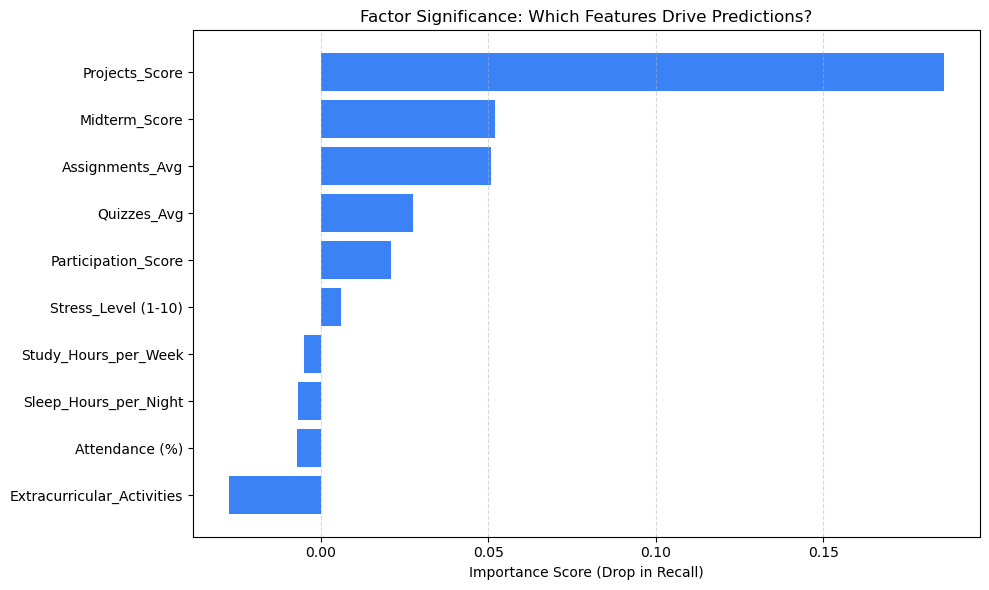

In [1]:
# =============================================================================
# FINAL YEAR PROJECT: STUDENT PERFORMANCE PREDICTION (FULL EVALUATION SUITE)
# Order: Baseline -> Main Model -> Robustness -> Ablation -> Feature Importance
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, recall_score, make_scorer, f1_score
)
from sklearn.inspection import permutation_importance

# Imbalanced-learn libraries
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
CSV_PATH = "Students Performance Dataset.csv"

# Feature Definitions
NUM_FEATURES = [
    "Attendance (%)", "Quizzes_Avg", "Assignments_Avg",
    "Midterm_Score", "Participation_Score", "Projects_Score",
    "Study_Hours_per_Week", "Sleep_Hours_per_Night", "Stress_Level (1-10)"
]
CAT_FEATURES = ["Extracurricular_Activities"]
TARGET_COL = "Grade"

# Load Data
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Dataset not found at {CSV_PATH}")
df = pd.read_csv(CSV_PATH)

# Drop ID columns
cols_to_drop = ["Student_ID", "First_Name", "Last_Name", "Email", "Final_Score", "Total_Score"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Handle Missing Values
for col in NUM_FEATURES:
    df[col] = df[col].fillna(df[col].median())
for col in CAT_FEATURES:
    df[col] = df[col].fillna(df[col].mode().iloc[0])

# Target Mapping (PASS/FAIL)
grade_to_binary = {"A": "PASS", "B": "PASS", "C": "PASS", "D": "FAIL", "F": "FAIL"}
df["Grade_Binary"] = df[TARGET_COL].map(grade_to_binary)

# Encode Target: Ensure FAIL=1 for Recall calculation
y = df["Grade_Binary"].map({"PASS": 0, "FAIL": 1}).values

# ==========================================
# PART 0: BASELINE BENCHMARK (Section 4.7.1)
# ==========================================
print("\n" + "="*60)
print(" PART 0: BASELINE BENCHMARK (Zero-Rule)")
print("="*60)

X = df[NUM_FEATURES + CAT_FEATURES].copy()

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Train Dummy Classifier (Strategies: 'most_frequent' always predicts PASS)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

# Evaluate
dummy_acc = accuracy_score(y_test, dummy_preds)
dummy_rec = recall_score(y_test, dummy_preds, pos_label=1)

print(f"Baseline Strategy: Guessing Majority Class ('PASS')")
print(f"Baseline Accuracy: {dummy_acc:.4f}")
print(f"Baseline Recall (Fail): {dummy_rec:.4f}")

# ==========================================
# PART 1: MAIN MODEL TRAINING (Section 4.4 & 4.5)
# ==========================================
print("\n" + "="*60)
print(" PART 1: MAIN MODEL TRAINING & PLOTTING")
print("="*60)

# Define Preprocessing Pipeline
numeric_transformer = SkPipeline(steps=[("scaler", MinMaxScaler())])
categorical_transformer = SkPipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUM_FEATURES),
        ("cat", categorical_transformer, CAT_FEATURES)
    ],
    remainder="drop"
)

# Define Main Model (Best Parameters from GridSearch: K=15, Manhattan, Distance)
main_model = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("knn", KNeighborsClassifier(n_neighbors=15, p=1, weights='distance'))
])

# Train
main_model.fit(X_train, y_train)

# Predict
y_prob = main_model.predict_proba(X_test)[:, 1]  # Probability of Fail
y_pred = (y_prob >= 0.5).astype(int)

# --- RESULTS ---
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred, pos_label=1)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc:.4f}")
print(f"Recall (Fail): {rec:.4f}")
print(f"ROC-AUC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["PASS", "FAIL"], digits=4))

# --- PLOTS ---
# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["PASS", "FAIL"], yticklabels=["PASS", "FAIL"])
plt.title("Confusion Matrix (Binary PASS vs FAIL)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_binary.png", dpi=150)
print(" [Saved] confusion_matrix_binary.png")
plt.close()

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("roc_curve.png", dpi=150)
print(" [Saved] roc_curve.png")
plt.close()

# ==========================================
# PART 2: ROBUSTNESS CHECK (Section 4.7.2)
# ==========================================
print("\n" + "="*60)
print(" PART 2: ROBUSTNESS CHECK (Split Testing)")
print("="*60)
print(f"{'Split (Train:Test)':<20} | {'Accuracy':<10} | {'Recall (Fail)':<15}")
print("-" * 55)

test_sizes = [0.10, 0.20, 0.30, 0.40] # 90:10, 80:20, 70:30, 60:40

for ts in test_sizes:
    # Re-split data
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=ts, random_state=42, stratify=y
    )
    
    # Re-train fresh model
    robust_model = ImbPipeline(steps=[
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=15, p=1, weights='distance'))
    ])
    robust_model.fit(X_tr, y_tr)
    
    # Evaluate
    preds = robust_model.predict(X_te)
    acc_r = accuracy_score(y_te, preds)
    rec_r = recall_score(y_te, preds, pos_label=1)
    
    split_name = f"{int((1-ts)*100)} : {int(ts*100)}"
    print(f"{split_name:<20} | {acc_r:.4f}     | {rec_r:.4f}")

# ==========================================
# PART 3: FEATURE IMPACT ANALYSIS (Section 4.7.4)
# ==========================================
print("\n" + "="*60)
print(" PART 3: FEATURE IMPACT ANALYSIS (Ablation)")
print("="*60)
print(f"{'Feature Set':<25} | {'Accuracy':<10} | {'Recall (Fail)':<15}")
print("-" * 55)

# Define Subsets
FEATS_ACADEMIC = [
    "Attendance (%)", "Quizzes_Avg", "Assignments_Avg",
    "Midterm_Score", "Participation_Score", "Projects_Score"
]
FEATS_ALL = NUM_FEATURES + CAT_FEATURES

subsets = {
    "Academic Only": FEATS_ACADEMIC,
    "Full (Academic+Behavior)": FEATS_ALL
}

# Fix split to 80:20 for fair comparison
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    df, y, test_size=0.20, random_state=42, stratify=y
)

for name, features in subsets.items():
    # Filter Data
    X_train_sub = X_tr_b[features]
    X_test_sub = X_te_b[features]
    
    # Identify Num/Cat for this subset
    curr_num = [c for c in features if c in NUM_FEATURES]
    curr_cat = [c for c in features if c in CAT_FEATURES]
    
    # Dynamic Preprocessor
    sub_preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, curr_num),
        ("cat", categorical_transformer, curr_cat)
    ])
    
    # Train
    bench_model = ImbPipeline(steps=[
        ("preprocess", sub_preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=15, p=1, weights='distance'))
    ])
    bench_model.fit(X_train_sub, y_tr_b)
    
    # Evaluate
    preds = bench_model.predict(X_test_sub)
    acc_b = accuracy_score(y_te_b, preds)
    rec_b = recall_score(y_te_b, preds, pos_label=1)
    
    print(f"{name:<25} | {acc_b:.4f}     | {rec_b:.4f}")

# ==========================================
# PART 4: FACTOR SIGNIFICANCE ANALYSIS (Section 4.7.5)
# ==========================================
print("\n" + "="*60)
print(" PART 4: FACTOR SIGNIFICANCE ANALYSIS (Permutation Importance)")
print("="*60)

# Use the trained 'main_model' and the test set (X_test, y_test)
# We measure the drop in 'f1' score (weighted) or 'recall' to see what matters most
result = permutation_importance(
    main_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='recall'  # saya sgt care psl  detecting Failures :) 
)

# Organize Results
sorted_idx = result.importances_mean.argsort()
features = np.array(NUM_FEATURES + CAT_FEATURES)

print(f"{'Feature':<30} | {'Importance (Recall Drop)':<15}")
print("-" * 50)
for i in sorted_idx[::-1]:
    print(f"{features[i]:<30} | {result.importances_mean[i]:.4f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(features[sorted_idx], result.importances_mean[sorted_idx], color='#3b82f6')
plt.xlabel("Importance Score (Drop in Recall)")
plt.title("Factor Significance: Which Features Drive Predictions?")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
print("\n [Saved] feature_importance.png")
print("\nAll Benchmark Tests Complete.")
plt.show()